Group member: Marel Arturo Castro & Ning Tian (100563101)

<!--- cSpell:enable --->

### **Introduction**

The goal of the assignment is to craft a predictive model that will forecast customers who are most likely to invest in a term deposit. This script will employ the use of KNN and decision trees alongside the machine learning technique XGBoost. Both of these methods will be adjusted with hyperparameter optimization.

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score,KFold
from sklearn import tree,set_config,metrics
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, MinMaxScaler, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif

### **Exploratory Data Analysis**

The Bank_01 file contains 11,000 observations consisting of 16 predictors and one target variable (deposit). The predictors have 7 numerical (`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`) and 9 categorical variables (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`). The target variable `deposit` is categorical and binary. 

For data cleaning, the data set has missing values in the `job` (169) and `education` (316) column and so within our pipeline we utilized the `SimpleImputer` function to classify the missing values into its own category of "unknown". Since `education` is an ordinal variable, the column was coded with `OrdinalEncoder`, as: unknown, primary, secondary, and tertiary. `Job` is nominal and was coded with `oneHotEncoder` so the observations were classified across multiple columns for each unique job type. The decision to use `SimpleImputer` for the median instead of the mean to impute data was to prevent the introduction of bias and determine whether those who refused to enter in that information were more or less likely to subscribe to a term deposit. 


In [2]:
data = pd.read_pickle('bank_01.pkl')
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        10831 non-null  object
 2   marital    11000 non-null  object
 3   education  10684 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


,age,balance,day,duration,campaign,pdays,previous
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.00000,11000.000000,11000.000000
mean,41.252727,1529.139273,15.660818,372.524909,2.50800,51.308636,0.828000
std,11.940474,3217.396248,8.417970,347.515713,2.72221,108.782842,2.282936
min,18.000000,-6847.000000,1.000000,2.000000,1.00000,-1.000000,0.000000
25%,32.000000,122.750000,8.000000,138.000000,1.00000,-1.000000,0.000000
50%,39.000000,549.500000,15.000000,255.000000,2.00000,-1.000000,0.000000
75%,49.000000,1711.000000,22.000000,498.000000,3.00000,20.250000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.00000,854.000000,58.000000


The shape of the data set reveal that that there are no constant columns since every feature contains more than one unique variable. There are also no ID columns or any type of indexing. Crucially, the dataset is modestly imbalanced since 47.5% of the customers did subscribe to a term deposit, making this a prime dataset for a classification problem since any predictive models will sort potential data customers into either subscribing to a term deposit or not. 

Lastly, we are given that cardinality, of the categorical variables, there are 12 job types, 3 marital statuses, 3 statuses on how they are contacted and a binaries on: if client has defaulted on their credit, if they have a home loan, and if they have non-home loan.


In [3]:
shape = data.shape
numeric_cols = data.select_dtypes(include="int64").columns.tolist()
categorical_cols = data.select_dtypes(include="object").columns.tolist()
cardinality = {col:data[col].nunique() for col in categorical_cols}
miss_count = data.isnull().sum()
constant_cols = [col for col in data.columns if data[col].nunique() == 1]
deposit_info = data['deposit'].value_counts()
pdays_des = data['pdays'].describe()
pdays_minus1_count = (data['pdays'] == -1).sum()
summary = {
    'shape': shape,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'cardinality': cardinality,
    'miss_count': miss_count,
    'constant_cols': constant_cols,
    'deposit_info': deposit_info,
    'pdays_des': pdays_des,
    'pdays_minus1_count': pdays_minus1_count,
}
summary

{'shape': (11000, 17),
 'numeric_cols': ['age',
  'balance',
  'day',
  'duration',
  'campaign',
  'pdays',
  'previous'],
 'categorical_cols': ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'poutcome',
  'deposit'],
 'cardinality': {'job': 12,
  'marital': 3,
  'education': 4,
  'default': 2,
  'housing': 2,
  'loan': 2,
  'contact': 3,
  'month': 12,
  'poutcome': 4,
  'deposit': 2},
 'miss_count': age            0
 job          169
 marital        0
 education    316
 default        0
 balance        0
 housing        0
 loan           0
 contact        0
 day            0
 month          0
 duration       0
 campaign       0
 pdays          0
 previous       0
 poutcome       0
 deposit        0
 dtype: int64,
 'constant_cols': [],
 'deposit_info': deposit
 no     5780
 yes    5220
 Name: count, dtype: int64,
 'pdays_des': count    11000.000000
 mean        51.308636
 std        108.782842
 min         -1.000000
 25%         -1.00

Lastly, the variable `pdays` presented a different challenge since it catalogues the last time a customer was contacted in time, but uses the value -1 to signify that they had never been contacted. To resolve this, we decided to transform the discrete variable into binary variable `whether_contacted` which will be the bimodal representation of the customers, a significant portion (74.6% "8203/11000") had never been contacted (with a range of up to 854 days) and so the -1 value was converted to 0 and any other customers with a positive value is converted to 1. 

Finally, for `pdays` we replaced -1 to Nan to avoid bias, and `SimpleImputer` will impute missing value with median.

In [4]:
print("pdays summary:")
print(data['pdays'].describe())
print("count of pdays == -1 (no contact):", (data['pdays'] == -1).sum())



pdays summary:
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64
count of pdays == -1 (no contact): 8203


In [5]:
def replace_pdays(x):
    x = x.copy()
    x["whether_contacted"] = (x["pdays"] != -1).astype(int)
    x["pdays"] = x["pdays"].replace(-1, np.nan)
    return x

feat_transformer = FunctionTransformer(replace_pdays, validate=False)

# preview transformed data
data_preview = feat_transformer.transform(data)
data_preview.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,whether_contacted
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,NaN,0,unknown,yes,0
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,NaN,0,unknown,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,NaN,0,unknown,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,NaN,0,unknown,yes,0
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,NaN,0,unknown,yes,0


Although `duration` may introduce information leakage in a real world setting, it is included in this work because it is explicitly provided in the competition data and significantly improves predictive accuracy.
As a result, the conclusions are restricted to the competition prediction task.

### **Outer and Inner Evaluation**

The code below is the setup for the outer and inner evaluation of the predictive model.

Firstly, within the data frame we drop `deposit` from `data` and instead store it in `y`. This is to prevent data leakage for the training model, since `deposit` is the target we wish to predict we don't want the models to see it in the training data. Afterwards, we print the dimensions of the data to verify and `x` has 11,000 observations and 16 predictors while `y` also has 11,000 observations with the target variable. 

Secondly, for outer evaluation, we split the data where 1/3 of the observations are for testing and the other 2/3 are for the training. Crucially, for inner evaluation, we stratify `y` so the class distribution of deposit is equal cross both sets to prevent bias. Then we initialize the cross validation object `cv` with 3 folds and with shuffling since to make the data more likely to be iid. Lastly, we double check that "deposit" is not within the data set.

In [6]:
x = data.drop(columns=['deposit'])
y = data['deposit']
print(x.shape, y.shape)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=1/3, random_state=100563101,stratify=y)
cv = KFold(n_splits=3, shuffle=True, random_state=100563101)
if 'deposit' in categorical_cols:
    categorical_cols.remove('deposit')


(11000, 16) (11000,)


### **Trees and KNN**

This list of pipelines is designed to handle the both the numerical columns and categorical columns by filling missing data and scaling. Firstly, the `StandardScaler`, `MinMaxScaler` and `RobustScaler` pipelines all impute with the median value of each column. The `StandardScaler` scales the values with the normal distribution with mean zero and standard deviation 1. The `MinMaxScaler` scales all values between 0 and 1 where 0 is the lowest value in the column and 1 is the highest value. The `RobustScaler` scales with the ratio of, the difference between the data point and the median, with the IQR.

For the categorical columns, they are split between ordinal and nonordinal where `education` is the only ordinal variable the data possesses.

The `nonordinal_transformer` pipeline is used to sort to replace the missing categorical entries with "unknown" as stated in our EDA the purpose is to identify if any patterns exist between those who refused to answer and the likelihood of subscribing to a term deposit. 

The `ordinal_transformer` pipeline is designed specifically for the `education` variable since it's the only variable with a logical ordering. Then we sort the observations in to 0 - 3, which represents unknown, primary, secondary, or tertiary, education achieved, respectively. This is done to both to preserve the logical order of the variable and to identify if any patterns exist between those who refused to answer and the likelihood of subscribing to a term deposit.

Lastly, the `preprocessor_sd`, `preprocessor_mm`, and `preprocessor_rb` objects combine the aforementioned pipelines to apply different preprocessing steps to different columns.

In [7]:
# numeric transformer
# using standard scaler
numeric_tramsformer_standard = Pipeline(steps=[
    ('imputation',SimpleImputer(strategy='median'),),
    # but our data has no missing values so this step will not change anything
    ('scaler',StandardScaler())
])
# using minmax scaler
numeric_tramsformer_minmax = Pipeline(steps=[
    ('imputation',SimpleImputer(strategy='median')),
    ('scaler',MinMaxScaler())
])
# using robust scaler
numeric_tramsformer_robust = Pipeline(steps=[
    ('imputation',SimpleImputer(strategy='median')),
    ('scaler',RobustScaler())
])

# categorical transformer
ordinal_catecols = ["education"]
nonordinal_catecols = categorical_cols.copy()
nonordinal_catecols.remove("education")
nonordinal_catecols = nonordinal_catecols + ["whether_contacted"]

nonordinal_transformer = Pipeline(steps=[
    ('imputation',SimpleImputer(strategy='constant',fill_value='unknown',missing_values=None),),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])
ordinal_transformer = Pipeline(steps=[
    ('imputation',SimpleImputer(strategy='constant',fill_value='unknown',missing_values=None)),
    ('ordinal',OrdinalEncoder(categories=[['unknown','primary','secondary','tertiary']]))
])
# column transformer
# using standard scaler for numeric columns
preprocessor_sd = ColumnTransformer(transformers=[
    ('num',numeric_tramsformer_standard,numeric_cols),
    ('ord',ordinal_transformer,ordinal_catecols),
    ('nonord',nonordinal_transformer,nonordinal_catecols)
])
# using minmax scaler for numeric columns
preprocessor_mm = ColumnTransformer(transformers=[
    ('num',numeric_tramsformer_minmax,numeric_cols),
    ('ord',ordinal_transformer,ordinal_catecols),
    ('nonord',nonordinal_transformer,nonordinal_catecols)
])
# using robust scaler for numeric columns
preprocessor_rb = ColumnTransformer(transformers=[
    ('num',numeric_tramsformer_robust,numeric_cols),
    ('ord',ordinal_transformer,ordinal_catecols),
    ('nonord',nonordinal_transformer,nonordinal_catecols)
])


X_feat = feat_transformer.transform(x_train)
preprocessor_sd.fit(X_feat)
cols = preprocessor_sd.get_feature_names_out() 
arr = preprocessor_sd.transform(X_feat)
df_after = pd.DataFrame(arr, columns=cols, index=X_feat.index)
df_after.head()

,num__age,num__balance,num__day,num__duration,num__campaign,num__pdays,num__previous,ord__education,nonord__job_admin.,nonord__job_blue-collar,...,nonord__month_may,nonord__month_nov,nonord__month_oct,nonord__month_sep,nonord__poutcome_failure,nonord__poutcome_other,nonord__poutcome_success,nonord__poutcome_unknown,nonord__whether_contacted_0,nonord__whether_contacted_1
1180,2.332274,-0.221405,-1.267387,-0.705224,0.182970,-0.083551,-0.349115,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1429,-0.697842,-0.386005,-0.911654,2.363123,-0.571017,-0.760873,0.937348,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3044,0.143857,0.623038,1.459896,-0.479866,-0.194024,0.147730,0.508527,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3889,-0.361163,-0.378753,-0.318767,-0.245839,0.182970,-0.083551,0.937348,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
7703,0.396366,-0.091491,0.155543,-0.904580,-0.571017,-0.083551,-0.349115,2.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


Here we define a dictionary named `pipelines` that will store the models. We created a dummy, decision tree, and 3 KNN models (one for each scaling method) to compare each model and determine how each scaling technique affects the KNN results.

In [8]:
pipelines = {}
pipelines["dummy"] = Pipeline([("feature", feat_transformer),("processing",preprocessor_sd),("model",DummyClassifier(strategy='most_frequent'))])
# here dummy model is scale insensitive, so the processing is just for comparison, same as tree model
pipelines["knn_standard"] = Pipeline([("feature", feat_transformer),("processing",preprocessor_sd),("model",KNeighborsClassifier())])
pipelines["knn_minmax"] = Pipeline([("feature", feat_transformer),("processing",preprocessor_mm),("model",KNeighborsClassifier())])
pipelines["knn_robust"] = Pipeline([("feature", feat_transformer),("processing",preprocessor_rb),("model",KNeighborsClassifier())])
pipelines["tree"] = Pipeline([("feature", feat_transformer),("processing",preprocessor_sd),("model",tree.DecisionTreeClassifier(random_state=100563101))])

To begin the hyperparameter optimization we print the default hyperparameter of the KNN. The results given reveal, we use default 5 nearest neighbors with the standard euclidean distance.

In [9]:
pipelines["knn_standard"].named_steps["model"].get_params()


{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

Additionally, we want the hyperparameters of the `DecisionTreeClassifier` and the output reveals that it uses the CART algorithm and defaults to the Gini criterion to make sure the nodes remain pure as possible and reduce how mixed a node is in class labels (MathWorks, 2025). Furthermore, the minimum samples needed to split a node is 2 and the minimum samples at a leaf node is 1 where every split is the best possible split at every node.

MathWorks. (2025). Growing decision trees. Retrieved December 22, 2025, from https://www.mathworks.com/help/stats/growing-decision-trees.html

In [10]:
pipelines["tree"].named_steps["model"].get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 100563101,
 'splitter': 'best'}

We will perform cross validation on each model type, by training and evaluating the model.

Baseline Classifier: This model will always predict the most common class and will serve as the benchmark to compare the other models, which represents the imbalance of no's to yes's (52.5%). This is reflected in the confusion matrix which displays all predictions as "no".

In [11]:
dummy_score = cross_val_score(
    pipelines["dummy"],
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)
print("Dummy Score:", dummy_score.mean())


Dummy Score: 0.5254332912732599


In [12]:
y_pred = cross_val_predict(
    pipelines["dummy"],
    x_train,
    y_train,
    cv=cv
)

labels = ["no", "yes"]
pd.DataFrame(
    confusion_matrix(y_train, y_pred,labels=labels),
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)

,Predicted no,Predicted yes
Actual no,3853,0
Actual yes,3480,0


KNN with Standardization: Better than the baseline and the dataset benefitted from the standardization and has an accuracy of 79.2%.

In [13]:
knn_sd_score = cross_val_score(
    pipelines["knn_standard"],
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)
print("KNN Standard Score:", knn_sd_score.mean())

KNN Standard Score: 0.7924463678281718


In [14]:
y_pred = cross_val_predict(
    pipelines["knn_standard"],
    x_train,
    y_train,
    cv=cv
)

pd.DataFrame(
    confusion_matrix(y_train, y_pred,labels=labels),
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)

,Predicted no,Predicted yes
Actual no,3216,637
Actual yes,885,2595


KNN with Min-Max Scaling: Performed worst of all the models with 70.6% accuracy.

In [15]:
knn_mm_score = cross_val_score(
    pipelines["knn_minmax"],
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)
print("KNN MinMax Score:", knn_mm_score.mean())

KNN MinMax Score: 0.7065329781097959


In [16]:
y_pred = cross_val_predict(
    pipelines["knn_minmax"],
    x_train,
    y_train,
    cv=cv
)

pd.DataFrame(
    confusion_matrix(y_train, y_pred,labels=labels),
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)

,Predicted no,Predicted yes
Actual no,3029,824
Actual yes,1328,2152


KNN with Robust Scaling: Better than the Min-Max scaling but not as strong as the standard scaling. Accuracy of 77.0%.

In [17]:
knn_rb_score = cross_val_score(
    pipelines["knn_robust"],
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)
print("KNN Robust Score:", knn_rb_score.mean())


KNN Robust Score: 0.7706266169978478


In [18]:

y_pred = cross_val_predict(
    pipelines["knn_robust"],
    x_train,
    y_train,
    cv=cv
)
pd.DataFrame(
    confusion_matrix(y_train, y_pred,labels=labels),
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)


,Predicted no,Predicted yes
Actual no,3129,724
Actual yes,958,2522


Decision Tree: A very strong output and comparable to the standardization scaled model which is expected since trees don't need scaling. Accuracy of 78.7%.

In [19]:
tree_score = cross_val_score(
    pipelines["tree"],
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)
print("Tree Score:", tree_score.mean())



Tree Score: 0.7837179542962079


In [20]:

y_pred = cross_val_predict(
    pipelines["tree"],
    x_train,
    y_train,
    cv=cv
)

pd.DataFrame(
    confusion_matrix(y_train, y_pred,labels=labels),
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)


,Predicted no,Predicted yes
Actual no,3090,763
Actual yes,823,2657


GridSearch Cross Validation: 

Next to evaluate our models we create an empty dictionary `param_grids` to store the different hyperparameters. The KNN pipeline will evaluate the hyperparameters where `model__n_neighbors` will determine how many nearest neighbors are needed. The hyperparameters for the tree is tuning for the maximum tree depth and the minimum samples needed to split a node.

In [21]:
param_grids = {}
param_grids["knn"] = {"model__n_neighbors": [3,5,7,9],"model__weights": ["uniform","distance"],}
param_grids["tree"] = {"model__max_depth": [3,5,7],"model__min_samples_split": [2,5,10]}


Using the `GridSearchCV` pipeline we perform hyperparameter tuning by training the model with the parameters we stored in `param_grids`. 

The KNN grid search had an average cross validation score of 79.9% which is an improvement over the default standardized KNN with an accuracy of 79.2%. The best hyperparameters were 7 neighbors with distances being weighted.

The decision tree grid search had an average cross validation score of 81.4% which is great improvement over the default which was 78.7%. The best hyperparameters was a maximum depth of 7. The tree depth of 7 can be attributed to this improvement since it can handle bias and variance better than the KNN model.


In [22]:
knn_grid = GridSearchCV(
        pipelines["knn_standard"],
        param_grids["knn"],
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )
knn_grid.fit(x_train, y_train)
print("best CV score:", knn_grid.best_score_)
print("best params:", knn_grid.best_params_)

best CV score: 0.7995377296708716
best params: {'model__n_neighbors': 7, 'model__weights': 'distance'}


In [23]:
tree_grid = GridSearchCV(
        pipelines["tree"],
        param_grids["tree"],
        cv=cv,
        scoring="accuracy",
        n_jobs=1
)
tree_grid.fit(x_train, y_train)
print("best CV score:", tree_grid.best_score_)
print("best params:", tree_grid.best_params_)

best CV score: 0.8139925608337043
best params: {'model__max_depth': 7, 'model__min_samples_split': 10}


Randomized Search Cross Validation:

We continue the hyperparameter tuning with the `RandomizedSearchCV` function from scikit-learn for the KNN model and decision tree. `param_random` will be the dictionary where we store the parameter search. For the KNN model we test for the best number of neighbors and the type of distance weighting. For the decision tree, we test for the optimal depth and the minimum number of samples required for a split node.

Using the standardized KNN pipeline we randomly sample hyperparameter combinations and fit the model. The KNN random tuning had an accuracy of 80% and the best model had 8 neighbors with distances being weighted. This is an improvement over the KNN grid search which had an accuracy of 79.9%.

Using the decision tree pipeline we randomly sample hyperparameter combinations and fit the model. The random tuning has an accuracy of 81.4% and the best model maximum depth of 7 and a needed 9 samples minimum to split a node. This is comparable to the decision tree grid search which also had an accuracy of 81.4%.

In [24]:
param_random = {}
param_random["knn"] = { "model__n_neighbors": range(3,10),"model__weights": ["uniform","distance"],}
param_random["tree"] = {"model__max_depth": range(3,8),"model__min_samples_split": range(2,11)}

In [25]:
knn_random = RandomizedSearchCV(
        pipelines["knn_standard"],
        param_random["knn"],
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )
knn_random.fit(x_train, y_train)
print("best CV score:", knn_random.best_score_)
print("best params:", knn_random.best_params_)

best CV score: 0.7995377296708716
best params: {'model__weights': 'distance', 'model__n_neighbors': 7}


In [26]:
tree_random = RandomizedSearchCV(
        pipelines["tree"],
        param_random["tree"],
        cv=cv,
        scoring="accuracy",
        n_jobs=1
)
tree_random.fit(x_train, y_train)
print("best CV score:", tree_random.best_score_)
print("best params:", tree_random.best_params_)

best CV score: 0.8074465853802755
best params: {'model__min_samples_split': 10, 'model__max_depth': 6}


### **Feature Selection for KNN**

According the previous HPO, we know the best `n_neighbors` is 7. So we reuse the optimal KNN hyperparameters. With those features we construct a new pipeline with feature engineering, standardized scaling, and feature selection, all with the KNN with specific hyperparameters.

In [27]:
best_neighbors = knn_grid.best_params_["model__n_neighbors"]
best_weights = knn_grid.best_params_["model__weights"]

knn_fs_pipeline  = Pipeline([("feature", feat_transformer),
                             ("processing",preprocessor_sd),
                             ("select", SelectKBest(mutual_info_classif)),
                             ("model",KNeighborsClassifier(
                                 n_neighbors=best_neighbors,
                                 weights=best_weights
                             ))])

`Param_grid_fs` will store `select_k` which will control how many features the model keeps which is testing every combination of features. `knn_fs_grid` is the grid search that uses three fold cross validation to evaluate each value of k and output the accuracy to measure performance. After fitting the mode, the output reveals the best average cross validation accuracy is 79.6% with 14 features.

In [28]:
param_grid_fs = {
    "select__k": list(range(1, x_train.shape[1]+1))
}
np.random.seed(100563101)
knn_fs_grid = GridSearchCV(
        knn_fs_pipeline,
        param_grid_fs,
        cv=cv,
        scoring="accuracy"
)
knn_fs_grid.fit(x_train, y_train)
print("best CV score:", knn_fs_grid.best_score_)
print("best params:", knn_fs_grid.best_params_)

best CV score: 0.7958558555543283
best params: {'select__k': 14}


We want to analyze the selected features so we retrieve the optimal features and their scores so we retrieve the `select` and `processing` objects from the pipeline. From the output it is revealed the strongest predictor is `num__duration` which is the length of the call, which is expected, the more relevant predictors are those related to the customers financial history. Those being, their balance, `balance`, and if they have been contacted before and the number of times they have been contacted, `pdays` and `previous`, respectively.

In [29]:
knn_best_selector = knn_fs_grid.best_estimator_.named_steps["select"]
feature_names_knn = knn_fs_grid.best_estimator_.named_steps["processing"].get_feature_names_out()

knn_fs_importances = pd.DataFrame({
    "feature": feature_names_knn,
    "importance": knn_best_selector.scores_
}).sort_values("importance", ascending=False)
knn_fs_importances.head(14)

,feature,importance
3,num__duration,0.159169
1,num__balance,0.046493
46,nonord__poutcome_success,0.044759
5,num__pdays,0.038832
48,nonord__whether_contacted_0,0.037822
31,nonord__contact_unknown,0.032787
47,nonord__poutcome_unknown,0.028237
26,nonord__housing_yes,0.027692
49,nonord__whether_contacted_1,0.027637
0,num__age,0.026065


Model Run Times:

The `run` function is set up to initialize a list to store each model's  run time to comapare it's computational complexity. For each model in the loop we use the `perf_counter` function from time `time` library to calculate the time it takes to fit each model. Additionally, we compare the single models and the tuned models by running each model again after tuning. The training times are measured on the training set for relative comparison between methods. The output dataframe reconfirms our earlier accuracy results and showcase that the increase in accuracy comes at an increase of fit time. The tuned models, such as `knn_random` and `tree_random` had a better accuracy but took 3 seconds compared to the single models' times of sub 1 second.

In [45]:
from sklearn.base import clone

def run(models, X, y, cv):
    rows = []
    for name, m in models.items():
        fit_times = []
        scores = []

        for train_idx, test_idx in cv.split(X, y):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            model = clone(m)

            start = time.perf_counter()
            model.fit(X_tr, y_tr)
            fit_times.append(time.perf_counter() - start)

            scores.append(model.score(X_te, y_te))

        rows.append({
            "Model": name,
            "Accuracy": np.mean(scores),
            "Fit time (s)": np.mean(fit_times)
        })

    return pd.DataFrame(rows)


results_single = run(pipelines, x_train, y_train, cv)

tuned_models = {
    "knn_grid": knn_grid,
    "tree_grid": tree_grid,
    "knn_random": knn_random,
    "tree_random": tree_random,
}

results_tuned = run(tuned_models, x_train, y_train, cv)

final_results = pd.concat([results_single, results_tuned])
final_results





,Model,Accuracy,Fit time (s)
0,dummy,0.525433,0.062999
1,knn_standard,0.792446,0.048995
2,knn_minmax,0.706533,0.052668
3,knn_robust,0.770627,0.049211
4,tree,0.783718,0.104327
0,knn_grid,0.797492,2.333109
1,tree_grid,0.813720,2.282116
2,knn_random,0.798038,3.158714
3,tree_random,0.812084,2.795317


### **Results and Final Model**

For the decision tree we use cross validation on the training set and evaluate final performance on a held back data. The `best.model.score` function, applies the best trained pipeline to the hidden data to compute accuracy for the classifiers. The test accuracy is 80.7% which will be the final estimate. 

In [31]:
best_model = tree_grid.best_estimator_
test_accuracy = best_model.score(x_test, y_test)
print("Outer test accuracy:", test_accuracy)


Outer test accuracy: 0.8069266430324515


Extracting and Plotting the Decision tree:

We extract the decision tree from the pipeline and the final feature names after processing. The `matplotlib` library is used to plot and visualize the tree. The first  node splits based on call duration and the Gini criterion, 49.9%, reveals and near even class mix. 

In [32]:
tree_model = best_model.named_steps["model"]
feature_names = best_model.named_steps["processing"].get_feature_names_out()



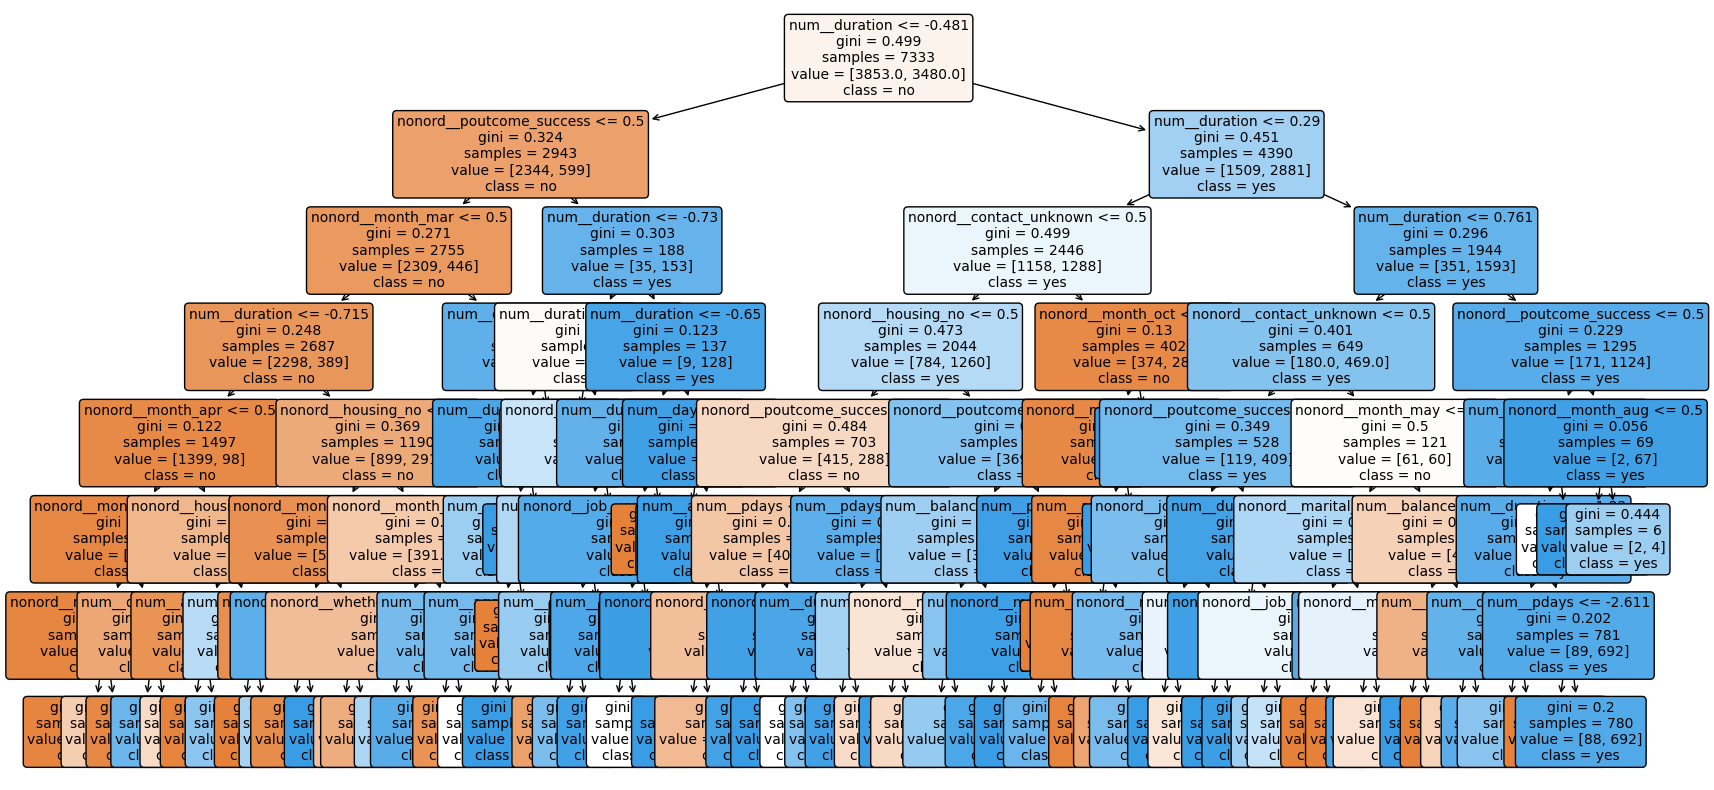

In [33]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["no", "yes"], 
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


Importance of Features:

We want to analyze the most important features so we output the list of the features from trained tree and rank their features by the Gini criterion. Features that are higher on the tree and used multiple times are more important such as `num_duration` and their financial past such as if they have been subscribed to a term deposit before, `poutcome` and if they have a home loan `housing`.

In [34]:
importances = tree_model.feature_importances_
import pandas as pd

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)
fi.head(10)

,feature,importance
3,num__duration,0.519830
46,nonord__poutcome_success,0.119885
31,nonord__contact_unknown,0.111751
25,nonord__housing_no,0.070936
39,nonord__month_mar,0.032976
5,num__pdays,0.019291
2,num__day,0.018987
42,nonord__month_oct,0.017229
32,nonord__month_apr,0.016350
1,num__balance,0.015649


Final Prediction:

The final model below makes use of the scikit-learn HTML visualization of the pipeline. Missing numerical variables were imputed with the median of the column and standardized, the ordinal variables were encoded using an ordinal encoder, and nominal categorical variables used one hot encoding. The final decision tree was trained using the Gini criterion with a maximum depth of 7. 

In [35]:
best_model.fit(x, y)

Pipeline(steps=[('feature',
                 FunctionTransformer(func=<function replace_pdays at 0x000002BA17C2D9E0>)),
                ('processing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputation',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputation',
                                                                   Si...
                                                 ('nonord',
                                                  Pipeline(steps=[('imputation',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 missing_values=None,
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome',
                                                   'whether_contacted'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=7, min_samples_split=10,
                                        random_state=100563101))])

We load the competition data set and create a copy. With that copy we use the `best_model` pipeline to generate predictions if a client would subscribe to a term deposit.

In [36]:
competition_data = pd.read_pickle('bank_competition.pkl')
competition_data.head()
x_pred = competition_data.copy()
y_pred = best_model.predict(x_pred)
y_pred

array(['no', 'yes', 'no', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'no',
       'no', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'no',
       'no', 'no', 'yes', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no',
       'no', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'yes',
       'yes', 'no', 'yes', 'no', 'yes', 'yes', 'no', 'no', 'no', 'no',
       'no', 'yes', 'no', 'yes', 'yes', 'no', 'no', 'yes', 'yes', 'no',
       'no', 'no', 'yes', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'yes',
       'no', 'no', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'yes',
       'no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'yes',
       'no', 'yes', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'no', 'no',
       'no', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'yes',
       'no', 'yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'no',
       'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no', 'yes', 'yes',
       'yes', 'no', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'y

The final model was saved using `joblib` and the predictions on the competition dataset were exported to a CSV file. The saved model can generate predictions that confirm that the pipeline was successful and preserved its predictive behavior.

In [37]:
import pandas as pd

pred_df = pd.DataFrame({
    "deposit": y_pred
})
pred_df.to_csv("predictions.csv", index=False)


In [38]:
import joblib

joblib.dump(best_model, "final_model.joblib")


['final_model.joblib']

In [39]:
loaded_model = joblib.load("final_model.joblib")
loaded_model.predict(x_pred[:5])


array(['no', 'yes', 'no', 'yes', 'yes'], dtype=object)

### **Open Choice Task: XGBoost**

The objective will be to use a machine learning technique, XGBoost, to compare the efficacy between ML and the KNN with decision tree model. To use XGBoost we need to process the data into a binary of 0 and 1's since the target is in the form "yes or no" so we import `LabelEncoder` to transform the data. Like our previous models we use a 33-67 split to test and train, respectively. 

In [40]:
from numpy import array
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

y_encoded = LabelEncoder().fit_transform(y)

xgb_train, xgb_test, ygb_train, ygb_test = train_test_split(
    x,
    y_encoded,
    test_size=1/3,
    random_state=100563101,
    stratify=y_encoded
)



The XGBoost pipeline uses `feat_transformer` to handle the -1's of `pdays` and we reuse the `preprocessor_sd` to standardize and encode categorical variables. The output gives the list of all the hyperparameters. The advantage given by XGBoost is its use of gradient boosted trees which handles non linear data better than KNN or decision tree models.

In [41]:
xgb_pipeline = Pipeline([
    ("feature", feat_transformer),
    ("processing", preprocessor_sd),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=100563101,
    ))
])
xgb_pipeline.named_steps["model"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 100563101,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

The hyperparameter grid `param_grid_xgb` sets up the search space to optimize the which combination of values will provide the highest accuracy. The Output, is the HTML representation of the pipeline, where we transform `pdays` and process the data using the column transformer to impute using the median and then standardize the column. Lastly, the model uses XGBoost to run the combinations of parameters.

In [42]:
param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__learning_rate": [0.01, 0.3]
}


xgb_Grid = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    cv=cv,           
    scoring="accuracy", 
    n_jobs=1
)
xgb_Grid.fit(xgb_train, ygb_train)


GridSearchCV(cv=KFold(n_splits=3, random_state=100563101, shuffle=True),
             estimator=Pipeline(steps=[('feature',
                                        FunctionTransformer(func=<function replace_pdays at 0x000002BA17C2D9E0>)),
                                       ('processing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputation',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'balance',
                                                                          'day',
                                                                          'd...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.3],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='accuracy')

The best parameters for XGBoost have a step size of .3, a maximum depth of 3 levels, n = 100 estimators, and using 80% of the rows per tree. The results is an accuracy of 86% which greatly out performs both the KNN and decision tree models.

Using the grid search we can confirm there is very little over fitting since after we compare the predicted values to the actual values we have a test accuracy of 86.3%

In [43]:
print("Best XGBoost Parameters:", xgb_Grid.best_params_)
print("Best ACC:", xgb_Grid.best_score_)


Best XGBoost Parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.3, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best ACC: 0.8603580461366652


In [44]:
ygb_pred = xgb_Grid.predict(xgb_test)
accuracy = metrics.accuracy_score(ygb_test, ygb_pred)
print("XGBoost Test Accuracy:", accuracy)

XGBoost Test Accuracy: 0.8636487592037088
